# UHPC Compressive Strength — Part 3: Model Interpretation

**Author:** K Flowers  
**Date:** January 2026

This notebook interprets the final XGBoost model for UHPC compressive strength developed in Notebook 02. Using SHAP (SHapley Additive exPlanations), it examines how individual mix design components contribute to model predictions. The goal is to better understand the relative importance of mix variables and how they influence predicted strength.

**Pipeline Position:** Notebook 3 of 3 — Model Interpretation
- 01_exploratory_analysis.ipynb
- 02_model_development.ipynb
- 03_model_interpretation.ipynb ← this notebook

**Objective:** Explain what the XGBoost model has learned about relationships between mix design components and compressive strength.

**Technical Approach:**
- Load the tuned model and data from Notebook 02 to ensure exact reproducibility
- Use SHAP values to understand how each feature influences predicted strength
- Analyze feature effects across all samples to find which mix components matter most
- Examine individual predictions to review reasoning across different mix designs

**Limitations:** 
- Interpretations are based on model behavior rather than professional materials science expertise.
- This notebook provides only a brief demonstration of SHAP interpretation techniques. Additional analyses are available for deeper investigation.

**Inputs:**
- `data/results/xgb_tuned_model.joblib` — Trained model from Notebook 02
- `data/results/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` — Train/test splits from Notebook 02

**Outputs:**
- SHAP summary and waterfall plots saved to `images/`

**Runtime:** ~10 minutes

**Table of Contents**
1. Configure Environment
2. Load Data
3. Compute Feature Impact (SHAP)
4. Analyze Global Feature Effects
5. Explain Individual Predictions
6. Conclusion
- References

---
## 1. Configure Environment

### 1.1 Import Libraries

In [ ]:
# Standard library
from pathlib import Path
import warnings

# Core data libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# Model persistence
import joblib

# SHAP — model interpretation
import shap

# Display
from IPython.display import display

print(f"Libraries imported successfully")
print(f"SHAP version: {shap.__version__}")

Libraries imported successfully
SHAP version: 0.50.0


### 1.2 Set Display and Plot Options

In [2]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


# Visualization settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Warnings
warnings.filterwarnings('ignore')

print("Display settings configured")

Display settings configured


### 1.3 Set Paths and Constants

In [ ]:
# Project paths
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
IMAGE_DIR = PROJECT_ROOT / "images"

# Create directories if needed
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# Input files
INPUT_FILE = DATA_DIR / "processed" / "uhpc_dataset_cleaned.csv"
MODEL_FILE = RESULTS_DIR / "xgb_tuned_model.joblib"

# Constants — must match notebook 02 for reproducibility
RANDOM_STATE = 42
UHPC_THRESHOLD = 150  # MPa — generally accepted threshold for UHPC classification

print("Paths and constants set")

### 1.4 Define Target and Features

In [4]:
# Define target variable and features (matching notebooks 01 and 02)

TARGET = 'compressive_strength'

FEATURES = [
    'cement', 'slag', 'silica_fume', 'limestone_powder', 'quartz_powder',
    'fly_ash', 'nano_silica', 'aggregate', 'water', 'fiber',
    'superplasticizer', 'temperature', 'age'
]

print(f"Target: {TARGET}")
print(f"Features: {len(FEATURES)} variables")

Target: compressive_strength
Features: 13 variables


---
## 2. Load Data

### 2.1 Load Train/Test Splits

Load the exact train/test splits saved by notebook 02 to ensure identical data.

In [5]:
# Load train/test splits saved by notebook 02
X_train = pd.read_csv(RESULTS_DIR / 'X_train.csv')
X_test = pd.read_csv(RESULTS_DIR / 'X_test.csv')
y_train = pd.read_csv(RESULTS_DIR / 'y_train.csv').squeeze()
y_test = pd.read_csv(RESULTS_DIR / 'y_test.csv').squeeze()

print(f"Train/Test Splits Loaded:")
print(f"  Training set: {len(X_train)} samples × {len(FEATURES)} features")
print(f"  Test set:     {len(X_test)} samples × {len(FEATURES)} features")

Train/Test Splits Loaded:
  Training set: 633 samples × 13 features
  Test set:     159 samples × 13 features


### 2.2 Load Trained Model

Load the tuned XGBoost model and its artifacts saved by notebook 02.

In [6]:
# Load trained model and artifacts from notebook 02
model_artifacts = joblib.load(MODEL_FILE)

model = model_artifacts['model']

print(f"Model loaded successfully")
print(f"  Source: {MODEL_FILE.name}")
print(f"  Model type: {model_artifacts['model_name']}")
print(f"  CV RMSE from tuning: {model_artifacts['cv_rmse']:.2f} MPa")

Model loaded successfully
  Source: xgb_tuned_model.joblib
  Model type: XGBoost
  CV RMSE from tuning: 7.98 MPa


### 2.3 Verify Model Performance

Quick check that the loaded model performs as expected on the test set.

In [7]:
# Verify model performance matches notebook 02
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"TEST SET PERFORMANCE")
print(f"  R²:   {r2:.3f}  (model explains {r2*100:.1f}% of variance in strength)")
print(f"  RMSE: {rmse:.2f} MPa")
print(f"  MAE:  {mae:.2f} MPa")

TEST SET PERFORMANCE
  R²:   0.978  (model explains 97.8% of variance in strength)
  RMSE: 5.93 MPa
  MAE:  4.25 MPa


## 3 Compute SHAP Values

**Methodology:** TreeExplainer will be used to compute exact SHAP values for the XGBoost model, assigning each feature a contribution to each prediction.

In [8]:
# Create SHAP TreeExplainer for the XGBoost model
explainer = shap.TreeExplainer(model)

# Compute SHAP values for the test set
shap_values = explainer(X_test)

print(f"SHAP values computed")
print(f"  Shape: {shap_values.values.shape} (samples × features)")
print(f"  Base value (mean prediction): {shap_values.base_values[0]:.2f} MPa")
print(f"  This is the model's average prediction before considering any specific feature values")

SHAP values computed


  Shape: (159, 13) (samples × features)
  Base value (mean prediction): 121.69 MPa
  This is the model's average prediction before considering any specific feature values


---
## 4. Analyze Global Feature Effects

**Methodology:** Global SHAP analysis will be used to show how each feature affects predictions across all samples, extending notebook 02's feature importance with directional information.

### 4.1 Plot SHAP Summary (Beeswarm)

Each dot represents one test sample. Position on the x-axis shows the feature's SHAP value (positive = increases predicted strength, negative = decreases it). Color shows the feature's actual value (red = high, blue = low).

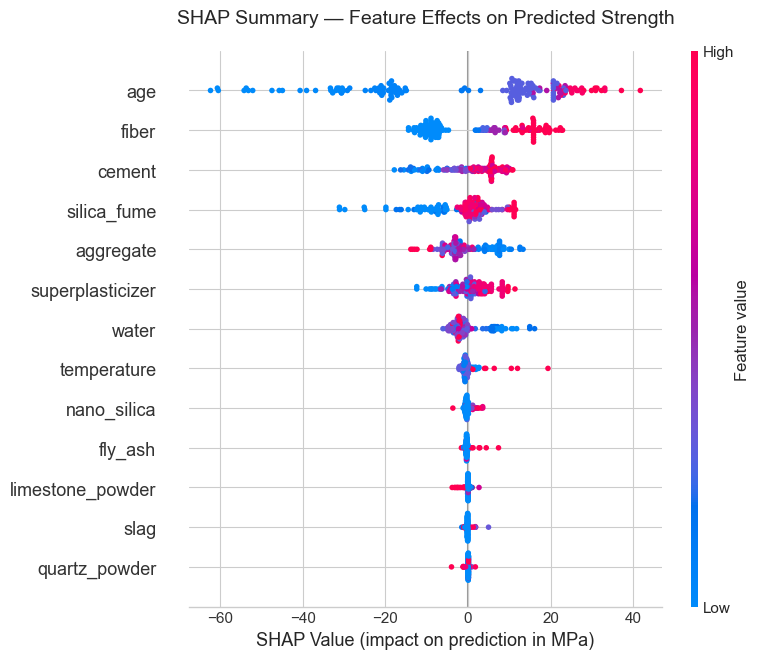

In [ ]:
# Create SHAP beeswarm summary plot
fig, ax = plt.subplots(figsize=(12, 8))
shap.plots.beeswarm(shap_values, show=False, max_display=13)
plt.title('SHAP Summary — Feature Effects on Predicted Strength', fontsize=14, pad=20)
plt.xlabel('SHAP Value (impact on prediction in MPa)')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Percent of samples with zero values (sorted to match beeswarm plot order)
zeros = (X_test == 0).mean() * 100
print("ZERO-VALUE RATES BY FEATURE\n")
for feat in zeros.sort_values().index:
    print(f"  {feat:20} {zeros[feat]:3.0f}%")

ZERO-VALUE RATES BY FEATURE

  cement                 0%
  aggregate              0%
  superplasticizer       0%
  water                  0%
  age                    0%
  temperature            0%
  silica_fume           22%
  fiber                 54%
  nano_silica           74%
  quartz_powder         85%
  limestone_powder      87%
  slag                  89%
  fly_ash               92%


**Interpretation:** 
- **Age, silica_fume, and fiber** show the widest SHAP value ranges, indicating they have the strongest influence on model predictions
- **Age** shows a clear directional pattern: high values (red) push predictions up, low values (blue) push predictions down
- **Fiber** displays a binary effect: positive lift when present, neutral when absent.
- **Silica_fume** displays strong positive effects at higher values, with SHAP contributions ranging from -10 to +40 MPa
- **Low-impact features:** Features with high zero-value rates (fly_ash, nano_silica, quartz_powder) show SHAP values tightly clustered around zero, suggesting limited influence even when present

### 4.2 Plot SHAP Bar (Mean Absolute Impact)

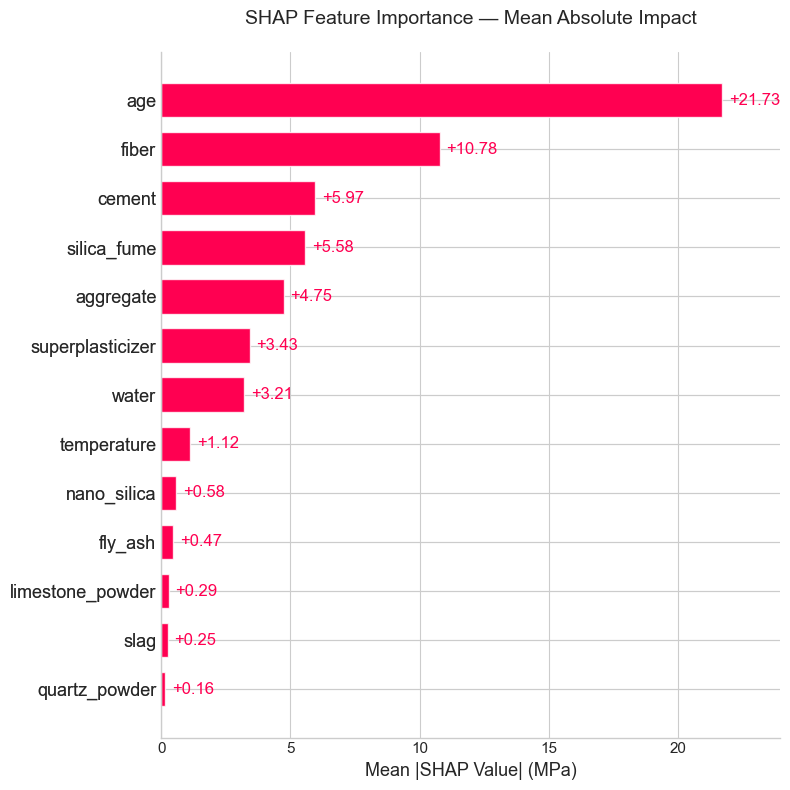

In [ ]:
# Create SHAP bar plot of mean absolute values
fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.bar(shap_values, show=False, max_display=13)
plt.title('SHAP Feature Importance — Mean Absolute Impact', fontsize=14, pad=20)
plt.xlabel('Mean |SHAP Value| (MPa)')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_bar_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**
- **Age** is the dominant predictor in both plots, contributing the largest mean absolute SHAP value
- **Age, fiber, silica_fume, cement** are the top 4 consistently across both plots, indicating these are the primary drivers of predicted strength in the model
- **Silica_fume** has a wide SHAP value spread in the beeswarm yet its mean absolute impact is slightly lower. This may mean silica_fume has high impact in specific samples
- **Low-impact features** (fly_ash, nano_silica, quartz_powder) show minimal contribution


---
## 5. Explain Individual Predictions

**Methodology:** Waterfall plots will be used to review individual predictions and understand which features drove each specific result.

### 5.1 Explain High-Strength Predictions

Compare two high-strength samples: one without fiber and one with fiber. This reveals how different mix designs can achieve UHPC-grade strength, and whether fiber contributes positively or negatively in high-strength formulations.

In [12]:
# Find two high-strength samples, one without fiber, one with fiber
high_strength_mask = y_pred >= UHPC_THRESHOLD

# Sample without fiber
high_no_fiber_idx = np.where(high_strength_mask & (X_test['fiber'] == 0))[0]
sample_high_no_fiber = high_no_fiber_idx[0]

# Sample with fiber
high_with_fiber_idx = np.where(high_strength_mask & (X_test['fiber'] > 0))[0]
sample_high_with_fiber = high_with_fiber_idx[0]

print("HIGH-STRENGTH SAMPLES COMPARISON")
print(f"\nSample A (no fiber, idx {sample_high_no_fiber}):")
print(f"  Predicted: {y_pred[sample_high_no_fiber]:.1f} MPa | Actual: {y_test.iloc[sample_high_no_fiber]:.1f} MPa")
print(f"  Key features: age={X_test.iloc[sample_high_no_fiber]['age']:.0f}d, "
      f"silica_fume={X_test.iloc[sample_high_no_fiber]['silica_fume']:.0f}, "
      f"fiber={X_test.iloc[sample_high_no_fiber]['fiber']:.0f}")

print(f"\nSample B (with fiber, idx {sample_high_with_fiber}):")
print(f"  Predicted: {y_pred[sample_high_with_fiber]:.1f} MPa | Actual: {y_test.iloc[sample_high_with_fiber]:.1f} MPa")
print(f"  Key features: age={X_test.iloc[sample_high_with_fiber]['age']:.0f}d, "
      f"silica_fume={X_test.iloc[sample_high_with_fiber]['silica_fume']:.0f}, "
      f"fiber={X_test.iloc[sample_high_with_fiber]['fiber']:.0f}")

HIGH-STRENGTH SAMPLES COMPARISON

Sample A (no fiber, idx 11):
  Predicted: 173.0 MPa | Actual: 168.0 MPa
  Key features: age=365d, silica_fume=90, fiber=0

Sample B (with fiber, idx 23):
  Predicted: 214.3 MPa | Actual: 201.4 MPa
  Key features: age=28d, silica_fume=434, fiber=156


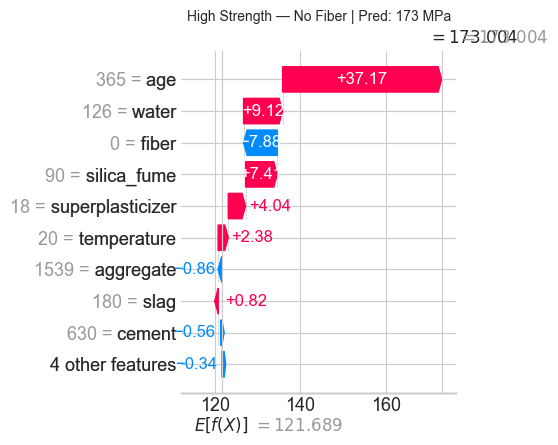

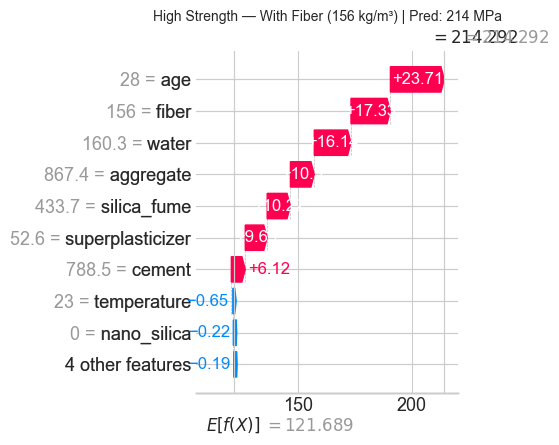

In [13]:
# Create waterfall plots for high-strength samples 
# Scale factor to reduce plot size (0.7 = 70% of default)
SCALE = 0.7

# Plot 1: No fiber
shap.plots.waterfall(shap_values[sample_high_no_fiber], show=False, max_display=10)
fig = plt.gcf()
default_size = fig.get_size_inches()
fig.set_size_inches(default_size[0] * SCALE, default_size[1] * SCALE)
plt.title(f'High Strength — No Fiber | Pred: {y_pred[sample_high_no_fiber]:.0f} MPa', fontsize=10)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_waterfall_high_no_fiber.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: With fiber
shap.plots.waterfall(shap_values[sample_high_with_fiber], show=False, max_display=10)
fig = plt.gcf()
default_size = fig.get_size_inches()
fig.set_size_inches(default_size[0] * SCALE, default_size[1] * SCALE)
plt.title(f'High Strength — With Fiber ({X_test.iloc[sample_high_with_fiber]["fiber"]:.0f} kg/m³) | Pred: {y_pred[sample_high_with_fiber]:.0f} MPa', fontsize=10)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_waterfall_high_with_fiber.png', dpi=150, bbox_inches='tight')
plt.show()

**High Strength Sample Interpretation:**

 The waterfall plots show two distinct patterns among high-strength predictions: one driven primarily by age (Sample A), and another where fiber and silica fume provide significant lift at a standard curing age (Sample B, fiber = +17 MPa). This suggests the model learned multiple paths to high compressive strength.

### 5.2 Explain Low-Strength Predictions

Compare two low-strength samples to understand what drives weak formulations. Since most low-strength samples lack fiber, different limiting factors will be evaluated.

In [ ]:
# Find two low-strength samples with different characteristics
low_strength_idx = np.where(y_pred < 80)[0]

# Sort by predicted strength to get lowest and a moderate-low sample
low_sorted = sorted(low_strength_idx, key=lambda x: y_pred[x])
sample_low_1 = low_sorted[0]  # Lowest predicted
sample_low_2 = low_sorted[len(low_sorted)//2]  # Middle of low-strength range

print("LOW-STRENGTH SAMPLES COMPARISON")
print(f"\nSample A (lowest, idx {sample_low_1}):")
print(f"  Predicted: {y_pred[sample_low_1]:.1f} MPa | Actual: {y_test.iloc[sample_low_1]:.1f} MPa")
print(f"  Key features: age={X_test.iloc[sample_low_1]['age']:.0f}d, "
      f"water={X_test.iloc[sample_low_1]['water']:.0f}, "
      f"fiber={X_test.iloc[sample_low_1]['fiber']:.0f}")

print(f"\nSample B (moderate-low, idx {sample_low_2}):")
print(f"  Predicted: {y_pred[sample_low_2]:.1f} MPa | Actual: {y_test.iloc[sample_low_2]:.1f} MPa")
print(f"  Key features: age={X_test.iloc[sample_low_2]['age']:.0f}d, "
      f"water={X_test.iloc[sample_low_2]['water']:.0f}, "
      f"fiber={X_test.iloc[sample_low_2]['fiber']:.0f}")

LOW-STRENGTH SAMPLES COMPARISON

Sample A (lowest, idx 8):
  Predicted: 35.1 MPa | Actual: 37.1 MPa
  Key features: age=3d, water=192, fiber=0

Sample B (moderate-low, idx 103):
  Predicted: 62.6 MPa | Actual: 53.1 MPa
  Key features: age=1d, water=202, fiber=0


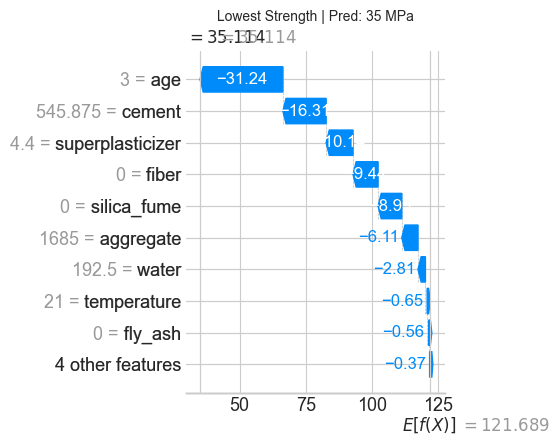

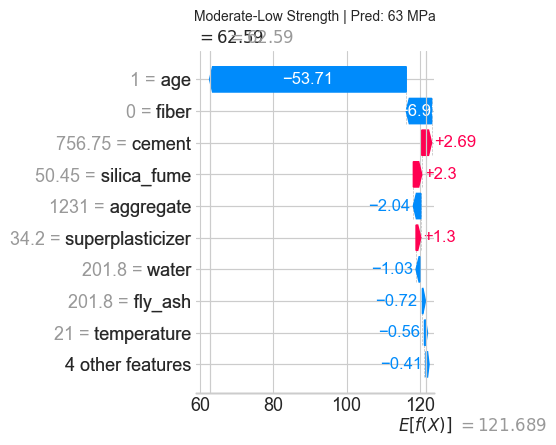

In [ ]:
# Create waterfall plots for low-strength samples
SCALE = 0.7

# Plot 1: Lowest strength
shap.plots.waterfall(shap_values[sample_low_1], show=False, max_display=10)
fig = plt.gcf()
default_size = fig.get_size_inches()
fig.set_size_inches(default_size[0] * SCALE, default_size[1] * SCALE)
plt.title(f'Lowest Strength | Pred: {y_pred[sample_low_1]:.0f} MPa', fontsize=10)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_waterfall_lowest.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Moderate-low strength
shap.plots.waterfall(shap_values[sample_low_2], show=False, max_display=10)
fig = plt.gcf()
default_size = fig.get_size_inches()
fig.set_size_inches(default_size[0] * SCALE, default_size[1] * SCALE)
plt.title(f'Moderate-Low Strength | Pred: {y_pred[sample_low_2]:.0f} MPa', fontsize=10)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_waterfall_moderate_low.png', dpi=150, bbox_inches='tight')
plt.show()

**Low Strength Sample Interpretation:**

Both low-strength samples are limited primarily by early curing age, with fiber absent in both cases. The model accurately predicts the 3-day sample (35 vs 37 MPa) but overestimates the 1-day sample by 10 MPa.  This may be due to underrepresented low-age behavior in training data (median age of 28 days).


---
## 6. Conclusion

**Interpretation Result:**

This high-level SHAP analysis evaluates the primary feature contributions driving each prediction. The purpose is to provide model evaluators or technical users with a starting point for identifying the mix design factors that most influence compressive strength.

**Key Findings:**
- **Age** is the dominant predictor across all samples
- **Fiber** provides significant lift when present (+17 MPa in high-strength samples)
- **Top 4 predictors** (age, fiber, silica_fume, cement) align with Notebook 02's feature importance rankings
- **Multiple paths to high strength** were identified: age-driven and fiber/silica_fume-driven

**Limitations:**
- Only a subset of test samples were examined; force plots could enable full exploration
- Interpretations reflect model behavior, not materials science expertise


## References

Lundberg, S.M., & Lee, S.I. (2017). A Unified Approach to Interpreting Model Predictions. *Advances in Neural Information Processing Systems*, 30.

Lundberg, S.M., et al. (2020). From Local Explanations to Global Understanding with Explainable AI for Trees. *Nature Machine Intelligence*, 2(1), 56-67.

- [SHAP Documentation](https://shap.readthedocs.io/)
- [XGBoost Documentation](https://xgboost.readthedocs.io/)